In [58]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans

%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],
          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [59]:
# ============================================================
# CLUSTERING - 1. Normalizar datos
# ============================================================
# Columnas numericas y categoricas
cols_numericas = ["year", "desplazamiento", "cilindros", "co2", "consumo_litros_milla"]
cols_categoricas = ["clase_tipo", "traccion_tipo", "transmision_tipo",
                     "combustible_tipo", "tamano_motor_tipo", "consumo_tipo", "co2_tipo"]

# 1) Dataset numerico: rellenar NaN con el promedio de cada columna, luego normalizar
df_num = df[cols_numericas].copy()
df_num = df_num.fillna(df_num.mean())

scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=cols_numericas, index=df_num.index)

# 2) Dataset categorico: transformar a variables dummy (one-hot encoding)
df_cat = df[cols_categoricas].copy()
df_cat_dummies = pd.get_dummies(df_cat)

# Explicacion: get_dummies transforma cada categoria unica de una variable categorica en una
# nueva columna binaria (0/1), donde 1 indica que esa observacion pertenece a esa categoria.
# Por ejemplo, la columna "combustible_tipo" con valores "Normal"/"Premium" se convierte en dos
# columnas: "combustible_tipo_Normal" y "combustible_tipo_Premium", cada una con 0 o 1.

# 3) Unir ambos datasets procesados
df_procesado = pd.concat([df_num_scaled, df_cat_dummies], axis=1)
print("Dimensiones df_procesado:", df_procesado.shape)
df_procesado.head()

Dimensiones df_procesado: (36791, 36)


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


In [60]:
# ============================================================
# CLUSTERING - 2. Realizar ajuste mediante kmeans
# ============================================================
# 1) Ajustar kmeans con 8 clusters
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans.fit(df_procesado)

# 2) Asignar cluster a cada individuo y calcular centroides
df["cluster"] = kmeans.labels_
df_procesado["cluster"] = kmeans.labels_

centroides = pd.DataFrame(kmeans.cluster_centers_, columns=df_procesado.drop(columns="cluster").columns)
print("Centroides de cada cluster:")
print(centroides)

# 3) Resumen de cada cluster
# Promedio de las variables numericas por cluster
resumen_numerico = df.groupby("cluster")[cols_numericas].mean()
print("\nPromedio de variables numericas por cluster:")
print(resumen_numerico)

# Moda de las variables numericas (y categoricas) por cluster
resumen_moda = df.groupby("cluster")[cols_numericas + cols_categoricas].agg(lambda x: x.mode().iloc[0])
print("\nModa de variables numericas/categoricas por cluster:")
print(resumen_moda)

# Cantidad de individuos por cluster
print("\nCantidad de vehiculos por cluster:")
print(df["cluster"].value_counts().sort_index())

Centroides de cada cluster:
       year  desplazamiento  cilindros       co2  consumo_litros_milla  \
0  0.427318        0.223790   0.173637  0.304599              0.226412   
1  0.569367        0.169607   0.146057  0.240820              0.156357   
2  0.407666        0.331397   0.256796  0.354288              0.282121   
3  0.476969        0.450984   0.327266  0.410019              0.343261   
4  0.384236        0.585590   0.430797  0.510289              0.454503   
5  0.588730        0.362290   0.299545  0.354136              0.282247   
6  0.452443        0.562730   0.405562  0.501887              0.442585   
7  0.579550        0.269830   0.210005  0.305067              0.226473   

   clase_tipo_Camionetas  clase_tipo_Coche Familiar  \
0               0.126441                   0.097434   
1               0.007990                   0.117281   
2               0.181278                   0.084035   
3               0.304450                   0.017116   
4               0.259250      

k=5 -> inercia=102310.09
k=10 -> inercia=84705.94
k=20 -> inercia=67073.43
k=30 -> inercia=55953.93
k=50 -> inercia=44887.89
k=75 -> inercia=36797.32
k=100 -> inercia=30896.22
k=200 -> inercia=17625.99
k=300 -> inercia=11234.82


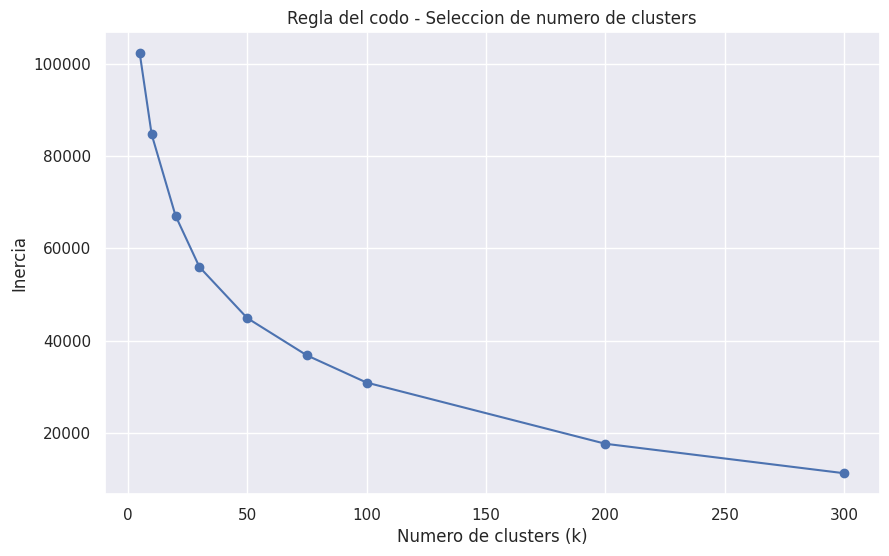

In [61]:
# ============================================================
# CLUSTERING - 3. Elegir numero de cluster (regla del codo)
# ============================================================
X = df_procesado.drop(columns="cluster") if "cluster" in df_procesado.columns else df_procesado

valores_k = [5, 10, 20, 30, 50, 75, 100, 200, 300]
inercias = []

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)
    print(f"k={k} -> inercia={km.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.title('Regla del codo - Seleccion de numero de clusters')
plt.grid(True)
plt.show()

# Conclusion: se busca el punto donde la reduccion de la inercia se estabiliza
# (el "codo" del grafico). A partir de ese k, agregar mas clusters ya no aporta
# una reduccion significativa de la inercia, por lo que ese valor es un buen
# candidato como numero apropiado de clusters para este dataset.

In [62]:
# ============================================================
# REDUCCION DE DIMENSIONALIDAD - Setup (celda de partida, pegar antes de los 3 ejercicios)
# ============================================================
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


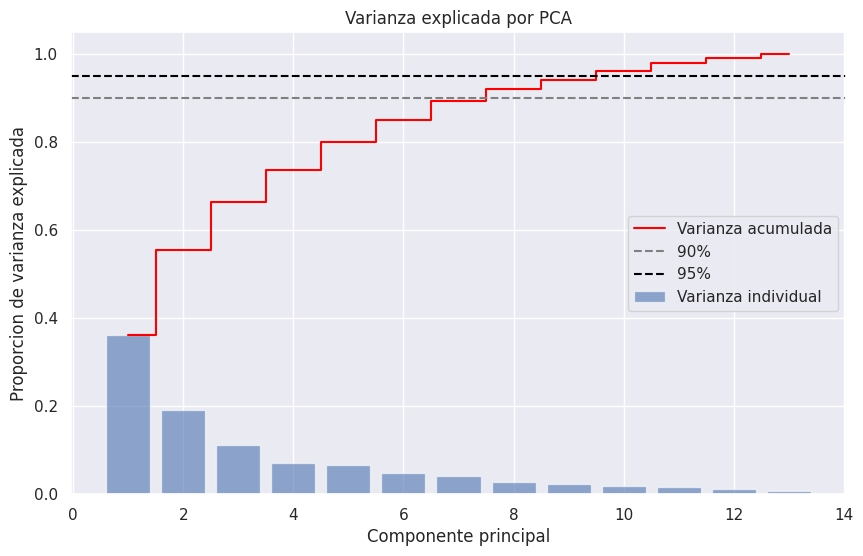

Componentes necesarios para explicar >=90% de la varianza: 8
Componentes necesarios para explicar >=95% de la varianza: 10


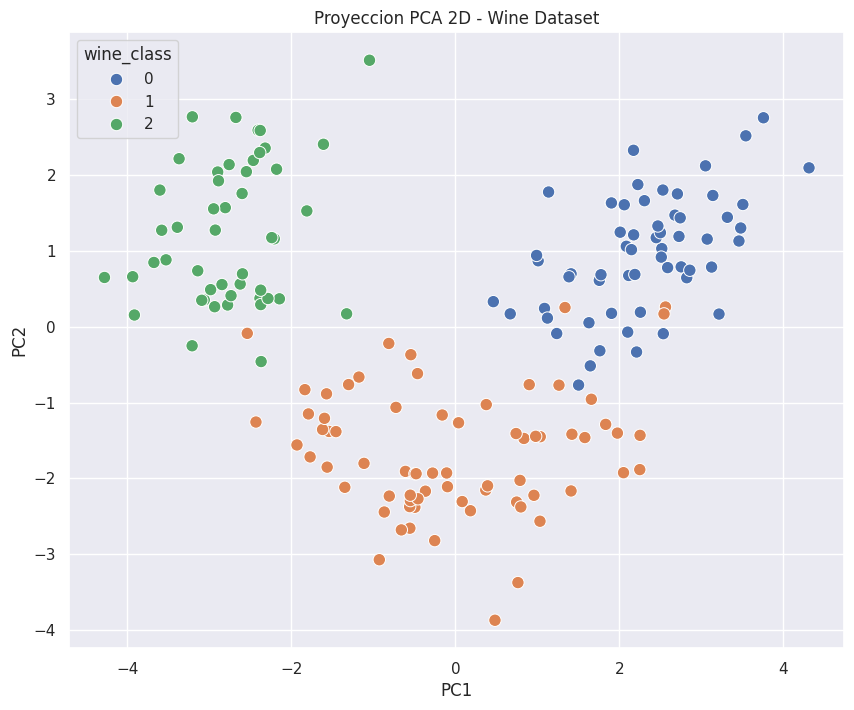

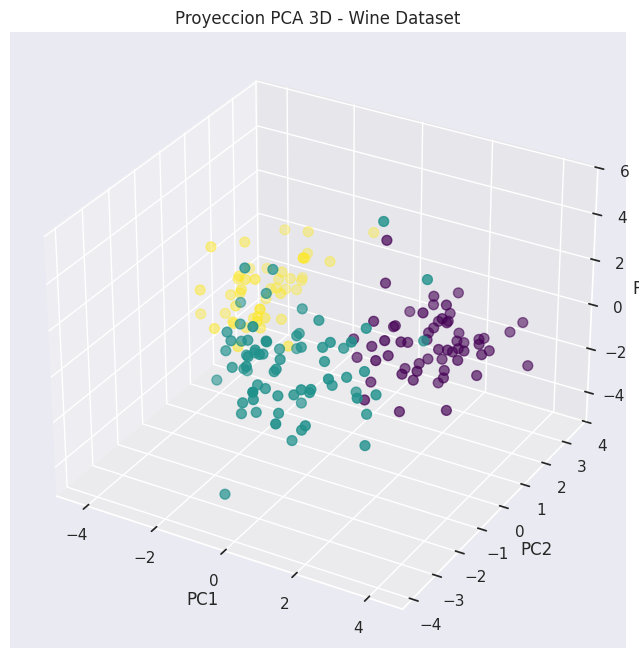

Loadings (PC1, PC2):
                                   PC1       PC2
flavanoids                    0.422934 -0.003360
total_phenols                 0.394661  0.065040
od280/od315_of_diluted_wines  0.376167 -0.164496
proanthocyanins               0.313429  0.039302
hue                           0.296715 -0.279235
proline                       0.286752  0.364903
alcohol                       0.144329  0.483652
magnesium                     0.141992  0.299634
ash                          -0.002051  0.316069
color_intensity              -0.088617  0.529996
alcalinity_of_ash            -0.239320 -0.010591
malic_acid                   -0.245188  0.224931
nonflavanoid_phenols         -0.298533  0.028779


In [63]:
# ============================================================
# REDUCCION DE DIMENSIONALIDAD - 1. Analisis detallado con PCA
# ============================================================
from sklearn.preprocessing import StandardScaler

X = wine[features].values
y = wine[target].values

# Estandarizar los datos (PCA es sensible a la escala)
X_scaled = StandardScaler().fit_transform(X)

# Ajustar PCA con todos los componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada por cada componente y acumulada
var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(var_acum)+1), var_acum, where='mid', color='red', label='Varianza acumulada')
plt.axhline(y=0.90, color='gray', linestyle='--', label='90%')
plt.axhline(y=0.95, color='black', linestyle='--', label='95%')
plt.xlabel('Componente principal')
plt.ylabel('Proporcion de varianza explicada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.show()

n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1
print(f"Componentes necesarios para explicar >=90% de la varianza: {n_90}")
print(f"Componentes necesarios para explicar >=95% de la varianza: {n_95}")

# Proyeccion en las 2 primeras componentes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y
df_pca_2d.head()

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='deep', s=80)
plt.title('Proyeccion PCA 2D - Wine Dataset')
plt.show()

# Proyeccion en 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='viridis', s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.title('Proyeccion PCA 3D - Wine Dataset')
plt.show()

# Loadings: coeficientes de cada variable original en cada componente
loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=features)
print("Loadings (PC1, PC2):")
print(loadings.sort_values('PC1', ascending=False))

# Interpretacion: las variables con mayor valor absoluto en cada componente son las
# que mas influyen en esa dimension. Por ejemplo, variables como flavanoids, total_phenols
# y od280/od315_of_diluted_wines suelen tener alto peso en PC1, mientras que color_intensity
# y hue suelen influir mas en PC2. En el grafico 2D/3D se observa que las tres clases de
# vino se separan de forma bastante clara, lo que indica que las primeras componentes
# capturan bien la estructura que distingue a las variedades.

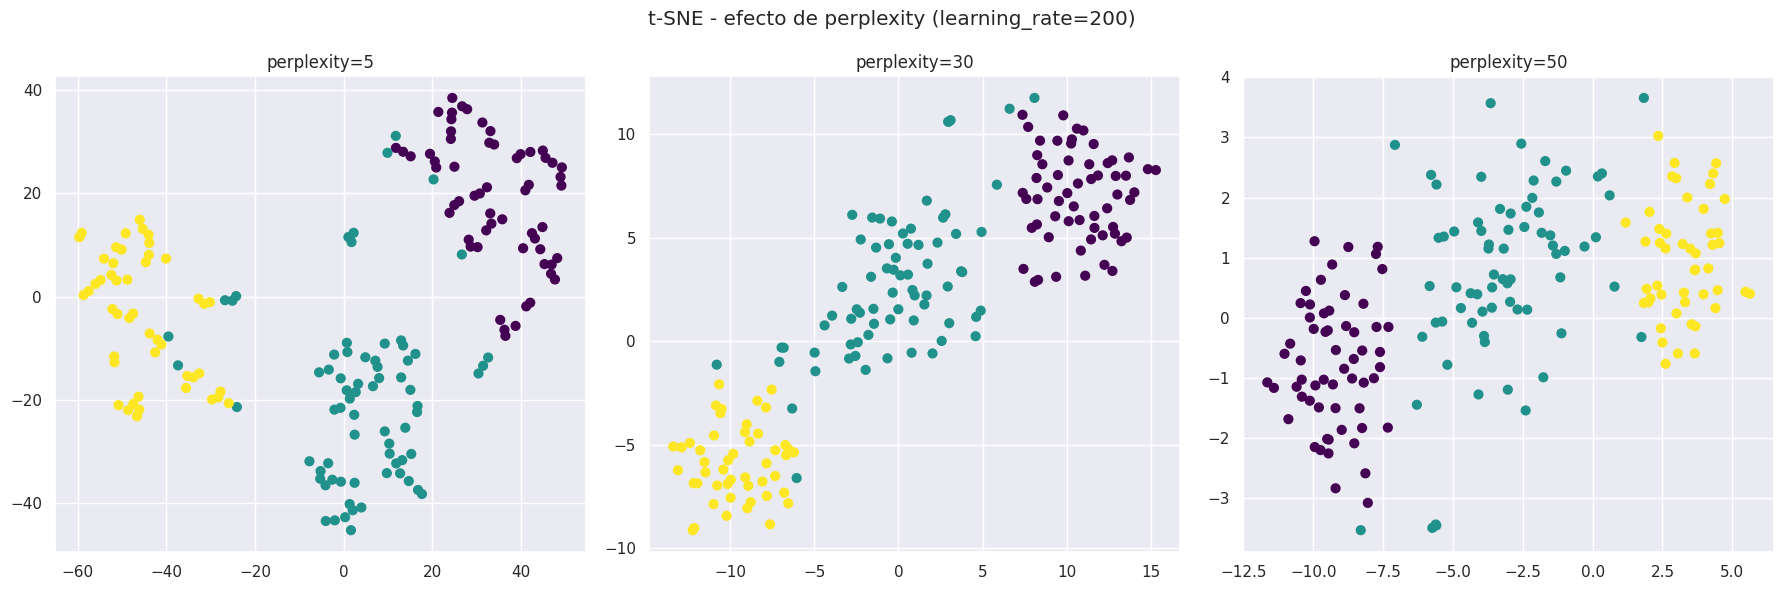

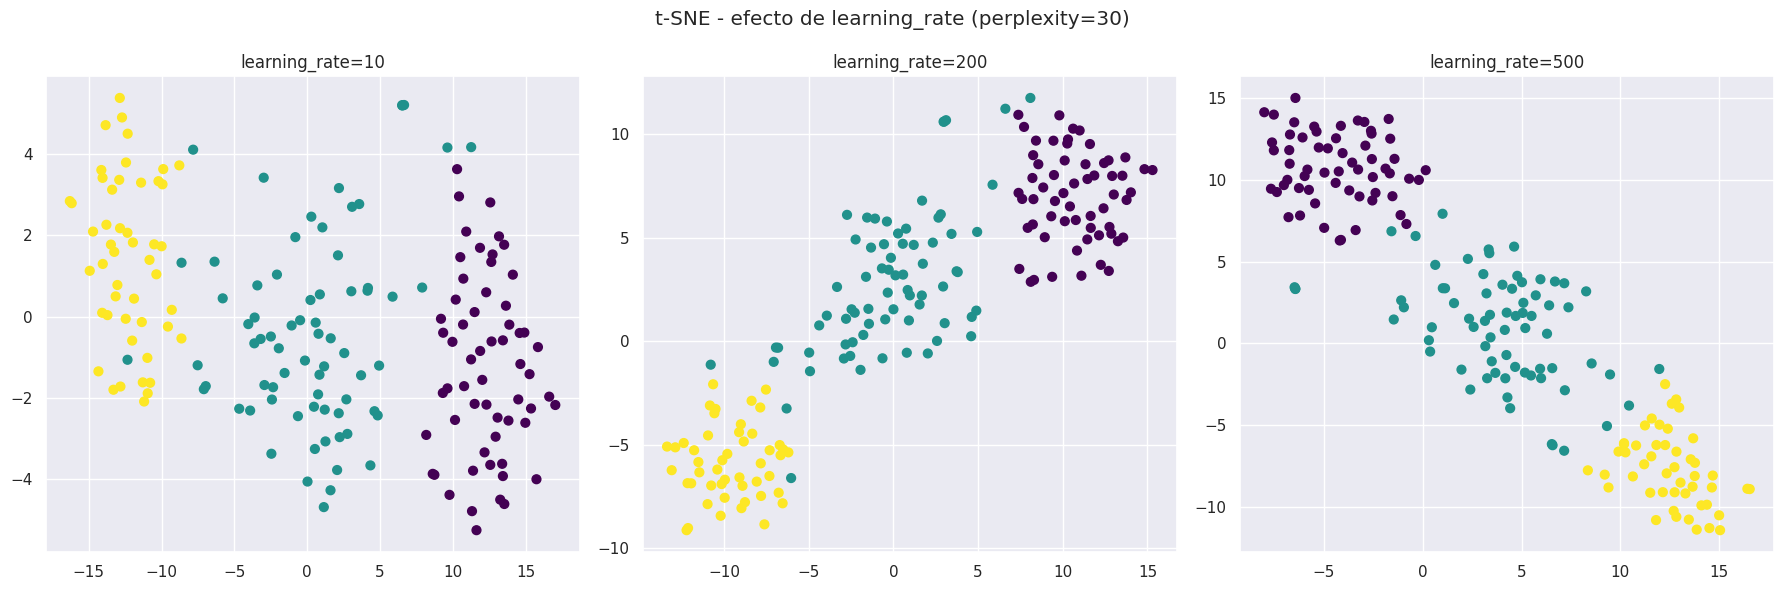

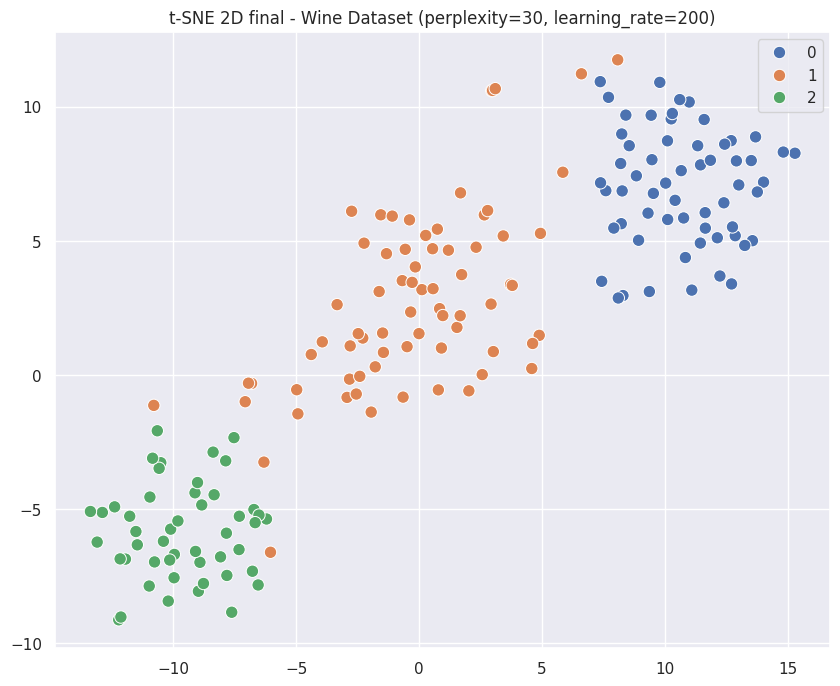

In [64]:
# ============================================================
# REDUCCION DE DIMENSIONALIDAD - 2. Analisis detallado con t-SNE
# ============================================================
perplexities = [5, 30, 50]
learning_rates = [10, 200, 500]

fig, axs = plt.subplots(1, len(perplexities), figsize=(18, 6))

for ax, perp in zip(axs, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X_scaled)
    sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=40)
    ax.set_title(f'perplexity={perp}')

plt.suptitle('t-SNE - efecto de perplexity (learning_rate=200)')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, len(learning_rates), figsize=(18, 6))

for ax, lr in zip(axs, learning_rates):
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=lr, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X_scaled)
    sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=40)
    ax.set_title(f'learning_rate={lr}')

plt.suptitle('t-SNE - efecto de learning_rate (perplexity=30)')
plt.tight_layout()
plt.show()

# Configuracion final elegida
tsne_final = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, init='pca')
X_tsne_final = tsne_final.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne_final[:, 0], y=X_tsne_final[:, 1], hue=y, palette='deep', s=80)
plt.title('t-SNE 2D final - Wine Dataset (perplexity=30, learning_rate=200)')
plt.show()

# Conclusion: valores bajos de perplexity generan grupos muy compactos y locales,
# mientras que valores altos tienden a suavizar la estructura y acercar los grupos.
# El learning_rate afecta la velocidad de convergencia: valores muy bajos o muy altos
# pueden generar visualizaciones distorsionadas ("clusters" artificiales). Con una
# configuracion intermedia (perplexity~30, learning_rate~200) t-SNE logra separar
# claramente las tres clases de vino, incluso mejor que PCA en algunos casos, ya que
# captura relaciones no lineales entre las muestras.

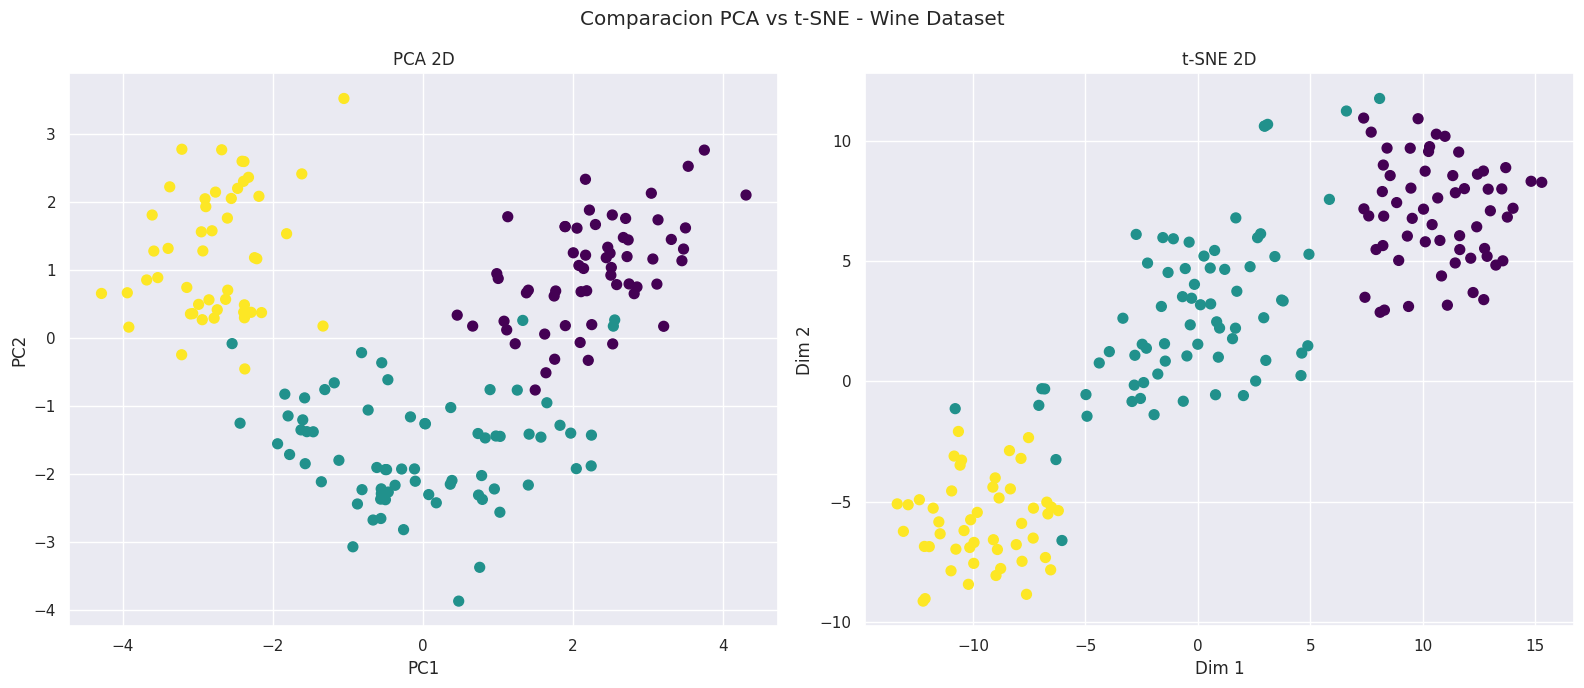

In [65]:
# ============================================================
# REDUCCION DE DIMENSIONALIDAD - 3. Comparacion entre PCA y t-SNE
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

axs[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', s=50)
axs[0].set_title('PCA 2D')
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')

axs[1].scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], c=y, cmap='viridis', s=50)
axs[1].set_title('t-SNE 2D')
axs[1].set_xlabel('Dim 1')
axs[1].set_ylabel('Dim 2')

plt.suptitle('Comparacion PCA vs t-SNE - Wine Dataset')
plt.tight_layout()
plt.show()

# Conclusiones:
# - PCA es un metodo LINEAL: proyecta los datos en las direcciones de maxima varianza,
#   es rapido, determinista y sus componentes son interpretables (loadings), pero puede
#   no capturar relaciones no lineales entre las observaciones.
# - t-SNE es un metodo NO LINEAL enfocado en preservar las relaciones de vecindad local,
#   por lo que suele generar agrupaciones visualmente mas claras y compactas, pero es
#   mas costoso computacionalmente, no es determinista (depende de random_state e
#   hiperparametros) y sus ejes no tienen una interpretacion directa como los de PCA.
# - En este dataset, ambas tecnicas logran separar razonablemente bien las tres
#   variedades de vino, lo que sugiere que la estructura de clases es en gran parte
#   lineal; sin embargo t-SNE tiende a mostrar una separacion mas nitida entre grupos.
# - En la practica: PCA es preferible cuando se busca interpretabilidad o como paso
#   previo de reduccion de dimensionalidad antes de entrenar otros modelos (reduce
#   ruido y costo computacional). t-SNE es preferible para exploracion visual y
#   deteccion de clusters cuando se sospecha de relaciones no lineales.
# - En datasets de alta dimension (muchas mas variables que Wine), la reduccion de
#   dimensionalidad es clave para visualizar patrones ocultos, reducir ruido/costo
#   computacional antes de aplicar algoritmos de ML, y facilitar la comunicacion de
#   resultados a personas no tecnicas.